# 03 - DCIR from a current pulse

DCIR is a pulse-test estimate of cell resistance. It is not a single
universal number: it depends on pulse duration, SOC, temperature, direction,
and the model or experiment used.

Docs:

- Experiment API: https://docs.pybamm.org/en/stable/source/api/experiment/experiment.html
- Experiment step functions: https://docs.pybamm.org/en/stable/source/api/experiment/experiment_steps.html

In [5]:
import os

os.environ.setdefault("PYBAMM_DISABLE_TELEMETRY", "true")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pybamm

print("PyBaMM version:", pybamm.__version__)

PyBaMM version: 26.6.2.0


## Important formulas

For a discharge pulse after rest:

$$
R_{DCIR}(\Delta t) =
\frac{V_{rest} - V_{pulse}(\Delta t)}
     {I_{pulse} - I_{rest}}
$$

The value changes with the chosen pulse duration `Delta t`. Short pulses
emphasize ohmic and fast kinetic effects; longer pulses include slower
concentration polarization.

In [6]:
def solve_dcir_pulse(
    initial_soc=0.5,
    pulse_c_rate=1.0,
    pulse_duration_s=100,
    rest_before_min=10,
    rest_after_min=5,
):
    model = pybamm.lithium_ion.DFN()
    experiment = pybamm.Experiment(
        [
            (
                f"Rest for {rest_before_min} minutes",
                f"Discharge at {pulse_c_rate}C for {pulse_duration_s} seconds",
                f"Rest for {rest_after_min} minutes",
            )
        ],
        period="1 second",
    )
    sim = pybamm.Simulation(
        model,
        parameter_values=model.default_parameter_values,
        experiment=experiment,
        output_variables=["Voltage [V]", "Current [A]"],
    )
    solution = sim.solve(initial_soc=initial_soc)
    return sim, solution


def extract_dcir(solution):
    cycle = solution.cycles[0]
    rest = cycle.steps[0]
    pulse = cycle.steps[1]

    v_rest = rest["Voltage [V]"].entries[-1]
    i_rest = rest["Current [A]"].entries[-1]
    v_pulse = pulse["Voltage [V]"].entries[-1]
    i_pulse = pulse["Current [A]"].entries[-1]

    resistance_ohm = (v_rest - v_pulse) / (i_pulse - i_rest)
    return {
        "V_rest": v_rest,
        "I_rest": i_rest,
        "V_pulse": v_pulse,
        "I_pulse": i_pulse,
        "R_ohm": resistance_ohm,
    }


sim, solution = solve_dcir_pulse(initial_soc=0.5)
result = extract_dcir(solution)
result

{'V_rest': np.float64(3.7449824270691714),
 'I_rest': np.float64(0.0),
 'V_pulse': np.float64(3.6420191388651535),
 'I_pulse': np.float64(0.680616),
 'R_ohm': np.float64(0.151279558817333)}

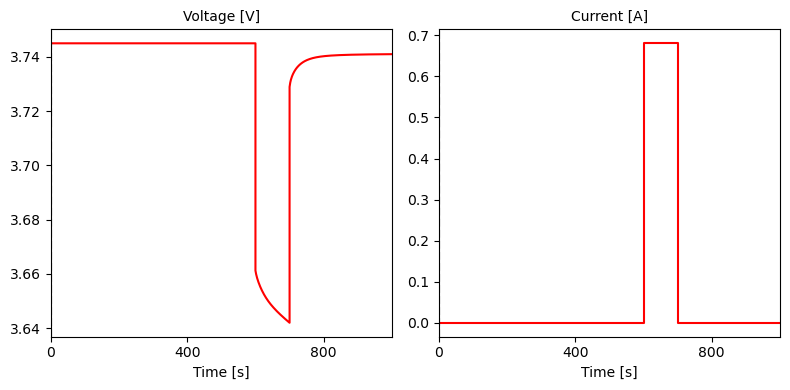

In [7]:
pybamm.QuickPlot(solution, ["Voltage [V]", "Current [A]"]).plot(0)

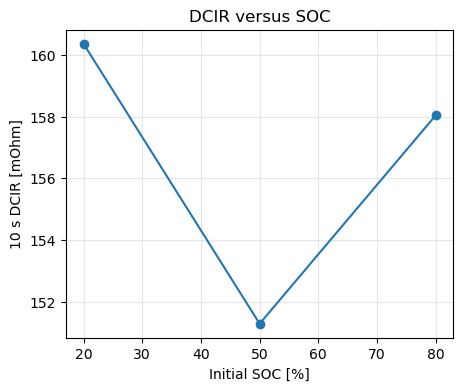

SOC 0.2: V_rest=3.692 V, V_pulse=3.583 V, R=160.4 mOhm
SOC 0.5: V_rest=3.745 V, V_pulse=3.642 V, R=151.3 mOhm
SOC 0.8: V_rest=3.849 V, V_pulse=3.741 V, R=158.0 mOhm


In [8]:
soc_values = [0.2, 0.5, 0.8]
rows = []

for soc in soc_values:
    _, sol = solve_dcir_pulse(initial_soc=soc)
    row = extract_dcir(sol)
    row["SOC"] = soc
    rows.append(row)

soc = np.array([row["SOC"] for row in rows])
dcir_mohm = 1000 * np.array([row["R_ohm"] for row in rows])

plt.figure(figsize=(5, 4))
plt.plot(100 * soc, dcir_mohm, "o-")
plt.xlabel("Initial SOC [%]")
plt.ylabel("10 s DCIR [mOhm]")
plt.title("DCIR versus SOC")
plt.grid(True, alpha=0.3)
plt.show()

for row in rows:
    print(
        f"SOC {row['SOC']:.1f}: "
        f"V_rest={row['V_rest']:.3f} V, "
        f"V_pulse={row['V_pulse']:.3f} V, "
        f"R={1000 * row['R_ohm']:.1f} mOhm"
    )

## Teaching prompts

- Change the pulse from 10 s to 1 s or 30 s.
- Compare charge and discharge pulses.
- Ask why DCIR depends on SOC even though the same model and parameter set are used.